# NYC Taxi-Zone Preprocessing

This notebook prepares the official TLC taxi-zone polygons for the later census-tract-to-taxi-zone spatial integration. Each meaningful operation is presented in a separate code cell so the workflow remains easy to follow without repeating the same checks. The Newark Airport (EWR) polygon is excluded because the research scope is limited to New York City's five boroughs.


## 1. Environment Setup


### 1.1 Import Required Libraries


In [62]:
from pathlib import Path

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from IPython.display import display


### 1.2 Configure Display Settings


In [63]:
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)


### 1.3 Define Input and Output Paths


In [64]:
DATA_DIR = Path(
    r"C:\Asia Pacific University\All Module Notes\Semister-5\Investigations"
    r"\FYP Semester 1\Progress\fyp\all_raw_data\taxi_zones"
)

SHAPEFILE_PATH = DATA_DIR / "taxi_zones.shp"
LOOKUP_PATH = DATA_DIR / "taxi_zone_lookup.csv"

OUTPUT_DIR = (
    DATA_DIR.parent.parent
    / "processed_outputs"
    / "taxi_zone"
)

CSV_OUTPUT_PATH = OUTPUT_DIR / "nyc_taxi_zones_cleaned.csv"
GPKG_OUTPUT_PATH = OUTPUT_DIR / "nyc_taxi_zones_cleaned.gpkg"

print("Shapefile:", SHAPEFILE_PATH)
print("Lookup table:", LOOKUP_PATH)
print("Output folder:", OUTPUT_DIR)


Shapefile: C:\Asia Pacific University\All Module Notes\Semister-5\Investigations\FYP Semester 1\Progress\fyp\all_raw_data\taxi_zones\taxi_zones.shp
Lookup table: C:\Asia Pacific University\All Module Notes\Semister-5\Investigations\FYP Semester 1\Progress\fyp\all_raw_data\taxi_zones\taxi_zone_lookup.csv
Output folder: C:\Asia Pacific University\All Module Notes\Semister-5\Investigations\FYP Semester 1\Progress\fyp\processed_outputs\taxi_zone


All project paths are defined once. The final GeoPackage filename and layer used later are kept consistent with the census-tract spatial-integration notebook.


## 2. Load and Inspect the Taxi-Zone Shapefile


### 2.1 Load the Polygon Dataset


In [ ]:
taxi_zones_raw = gpd.read_file(SHAPEFILE_PATH)
taxi_zones_raw.shape

(263, 7)

The source shapefile contains 263 polygon records, including the separate Newark Airport polygon.


### 2.2 Inspect the Columns and Records


In [66]:
print(taxi_zones_raw.dtypes)
display(taxi_zones_raw.head())


OBJECTID         int32
Shape_Leng     float64
Shape_Area     float64
zone            object
LocationID       int32
borough         object
geometry      geometry
dtype: object


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 192572.175, 933088.585 192604.97, 933121.56 192857.382, 933149.268 19297..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 1033439.643 170883.946, 1033473.265 170808.208, 1033504.66 170731.521, 10335..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 256638.616, 1026567.23 256589.859, 1026729.235 256481.356, 1026817.315 ..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 203711.502, 992061.716 203711.772, 992049.866 203627.244, 992045.713 203..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144173.418, 936387.922 143967.756, 936481.134 143911.788, 936499.881 1439..."


The source provides `LocationID`, borough and zone classifications together with polygon geometry. The stored source shape fields are unnecessary because any later area measurements are calculated directly from geometry.


### 2.3 Inspect the Coordinate Reference System


In [67]:
pd.Series({
    "crs": taxi_zones_raw.crs.to_string(),
    "epsg": taxi_zones_raw.crs.to_epsg(),
    "projected": taxi_zones_raw.crs.is_projected,
})


crs          EPSG:2263
epsg              2263
projected         True
dtype: object

The polygons use projected EPSG:2263. This is the coordinate system expected by the later spatial-integration workflow, where the census tracts are reprojected to match the taxi zones before area intersection.


## 3. Validate the Source Quality


### 3.1 Check the LocationID Key


In [68]:
identifier_check = pd.Series({
    "records": len(taxi_zones_raw),
    "unique_location_ids": taxi_zones_raw["LocationID"].nunique(),
    "missing_location_ids": taxi_zones_raw["LocationID"].isna().sum(),
    "duplicate_location_ids": taxi_zones_raw["LocationID"].duplicated().sum(),
})

display(identifier_check.to_frame("result"))


,result
records,263
unique_location_ids,263
missing_location_ids,0
duplicate_location_ids,0


All source polygons have complete and unique `LocationID` values, so the identifier can safely be used for lookup enrichment and later dataset integration.


### 3.2 Check Missing Attributes


In [69]:
taxi_zones_raw.drop(columns="geometry").isna().sum().to_frame("missing_values")


,missing_values
OBJECTID,0
Shape_Leng,0
Shape_Area,0
zone,0
LocationID,0
borough,0


No source attribute contains a missing value; therefore, no attribute imputation is required.


### 3.3 Check Geometry Quality


In [70]:
geometry_check = pd.Series({
    "missing_geometries": taxi_zones_raw.geometry.isna().sum(),
    "empty_geometries": taxi_zones_raw.geometry.is_empty.sum(),
    "invalid_geometries": (~taxi_zones_raw.geometry.is_valid).sum(),
    "geometry_types": taxi_zones_raw.geometry.geom_type.value_counts().to_dict(),
})

display(geometry_check.to_frame("result"))


,result
missing_geometries,0
empty_geometries,0
invalid_geometries,0
geometry_types,"{'Polygon': 240, 'MultiPolygon': 23}"


All polygons are present, non-empty and valid. Geometry repair is therefore unnecessary.


## 4. Load and Prepare the Lookup Table


### 4.1 Load the Lookup Table


In [71]:
lookup_raw = pd.read_csv(LOOKUP_PATH)
print("Lookup shape:", lookup_raw.shape)
display(lookup_raw.head())


Lookup shape: (265, 4)


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


The official lookup table contains 265 records and supplies the `service_zone` field. The two additional lookup-only identifiers represent non-polygon categories and do not enter the spatial dataset.


### 4.2 Prepare the Taxi-Zone Fields


In [72]:
taxi_zones = taxi_zones_raw.copy()
taxi_zones["LocationID"] = pd.to_numeric(
    taxi_zones["LocationID"], errors="raise"
).astype("int64")
taxi_zones["borough"] = taxi_zones["borough"].astype("string").str.strip()
taxi_zones["zone"] = taxi_zones["zone"].astype("string").str.strip()

taxi_zones[["LocationID", "borough", "zone"]].dtypes


LocationID             int64
borough       string[python]
zone          string[python]
dtype: object

### 4.3 Prepare the Lookup Fields


In [73]:
lookup = lookup_raw.copy()
lookup["LocationID"] = pd.to_numeric(
    lookup["LocationID"], errors="raise"
).astype("int64")
lookup["service_zone"] = lookup["service_zone"].astype("string").str.strip()

lookup[["LocationID", "service_zone"]].dtypes


LocationID               int64
service_zone    string[python]
dtype: object

Both joining keys are standardised to 64-bit integers, while surrounding whitespace is removed from the retained text classifications.


## 5. Add the Service-Zone Classification


### 5.1 Join the Lookup Field


In [74]:
taxi_zones = taxi_zones.merge(
    lookup[["LocationID", "service_zone"]],
    on="LocationID",
    how="left",
    validate="one_to_one",
)

taxi_zones.shape


(263, 8)

### 5.2 Validate the Lookup Join


In [75]:
join_check = pd.Series({
    "records_preserved": len(taxi_zones) == len(taxi_zones_raw),
    "unique_location_ids": taxi_zones["LocationID"].is_unique,
    "missing_service_zone_values": taxi_zones["service_zone"].isna().sum(),
    "missing_geometries": taxi_zones.geometry.isna().sum(),
})

display(join_check.to_frame("result"))


,result
records_preserved,True
unique_location_ids,True
missing_service_zone_values,0
missing_geometries,0


The one-to-one join preserves all 263 polygons and supplies a service-zone classification for every spatial record.


## 6. Restrict the Dataset to the Five NYC Boroughs


### 6.1 Define the Study Boroughs


In [76]:
NYC_BOROUGHS = [
    "Bronx", "Brooklyn", "Manhattan", "Queens", "Staten Island"
]


### 6.2 Identify the Record Outside the Study Area


In [77]:
excluded_zones = taxi_zones.loc[
    ~taxi_zones["borough"].isin(NYC_BOROUGHS),
    ["LocationID", "borough", "zone", "service_zone"],
]

display(excluded_zones)


,LocationID,borough,zone,service_zone
0,1,EWR,Newark Airport,EWR


The only polygon outside the selected boroughs is LocationID 1, representing Newark Airport (EWR). It is excluded because the project evaluates New York City's five boroughs.


### 6.3 Create the Final Five-Borough Dataset


In [78]:
final_columns = [
    "LocationID", "borough", "zone", "service_zone", "geometry"
]

final_gdf = taxi_zones.loc[
    taxi_zones["borough"].isin(NYC_BOROUGHS), final_columns
].copy()

final_gdf = final_gdf.sort_values("LocationID").reset_index(drop=True)
final_gdf.shape

display(pd.DataFrame({"column": final_gdf.columns}))


,column
0,LocationID
1,borough
2,zone
3,service_zone
4,geometry


After removing EWR, the final spatial dataset contains 262 taxi-zone polygons and five retained fields.


## 7. Inspect and Visualise the Final Dataset


### 7.1 Inspect the Final Structure


In [79]:
print(final_gdf.dtypes)
display(final_gdf.head())


LocationID               int64
borough         string[python]
zone            string[python]
service_zone    string[python]
geometry              geometry
dtype: object


,LocationID,borough,zone,service_zone,geometry
0,2,Queens,Jamaica Bay,Boro Zone,"MULTIPOLYGON (((1033269.244 172126.008, 1033439.643 170883.946, 1033473.265 170808.208, 1033504.66 170731.521, 10335..."
1,3,Bronx,Allerton/Pelham Gardens,Boro Zone,"POLYGON ((1026308.77 256767.698, 1026495.593 256638.616, 1026567.23 256589.859, 1026729.235 256481.356, 1026817.315 ..."
2,4,Manhattan,Alphabet City,Yellow Zone,"POLYGON ((992073.467 203714.076, 992068.667 203711.502, 992061.716 203711.772, 992049.866 203627.244, 992045.713 203..."
3,5,Staten Island,Arden Heights,Boro Zone,"POLYGON ((935843.31 144283.336, 936046.565 144173.418, 936387.922 143967.756, 936481.134 143911.788, 936499.881 1439..."
4,6,Staten Island,Arrochar/Fort Wadsworth,Boro Zone,"POLYGON ((966568.747 158679.855, 966615.256 158662.292, 966524.882 158822.266, 966153.394 159414.401, 967460.874 160..."


### 7.2 Summarise Taxi Zones by Borough


In [80]:
borough_summary = (
    final_gdf.groupby("borough")
    .size()
    .rename("taxi_zones")
)

display(borough_summary.to_frame())


,taxi_zones
borough,
Bronx,43
Brooklyn,61
Manhattan,69
Queens,69
Staten Island,20


The final records comprise 43 Bronx zones, 61 Brooklyn zones, 69 Manhattan zones, 69 Queens zones and 20 Staten Island zones, totalling 262.


### 7.3 Summarise Service-Zone Categories


In [81]:
service_zone_summary = (
    final_gdf.groupby("service_zone")
    .size()
    .rename("taxi_zones")
)

display(service_zone_summary.to_frame())


,taxi_zones
service_zone,
Airports,2
Boro Zone,205
Yellow Zone,55


### 7.4 Visualise the Five-Borough Coverage


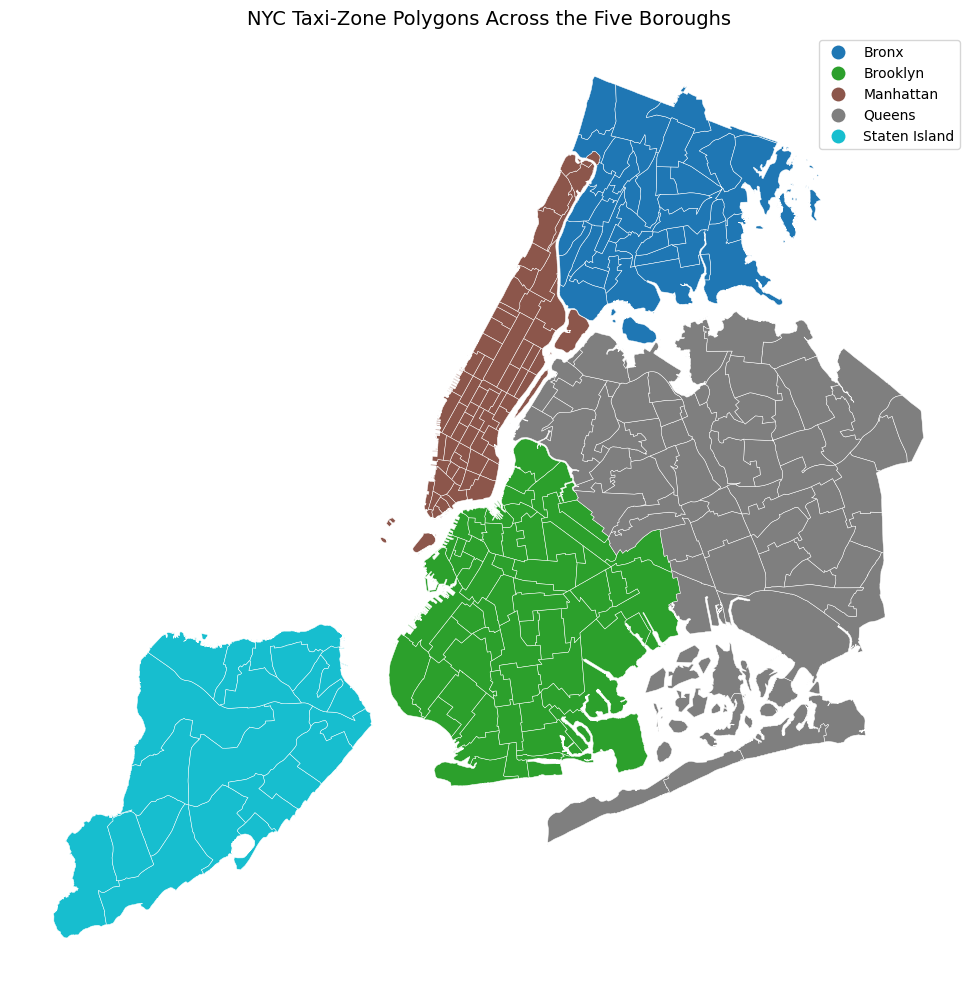

In [82]:
fig, ax = plt.subplots(figsize=(10, 10))
final_gdf.plot(
    column="borough",
    categorical=True,
    legend=True,
    edgecolor="white",
    linewidth=0.35,
    cmap="tab10",
    ax=ax,
)
ax.set_title("NYC Taxi-Zone Polygons Across the Five Boroughs", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()


The map confirms spatial coverage across all five boroughs without the separate Newark Airport polygon.


## 8. Save and Confirm the Integration Input


### 8.1 Create the Output Folder


In [83]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR


WindowsPath('C:/Asia Pacific University/All Module Notes/Semister-5/Investigations/FYP Semester 1/Progress/fyp/processed_outputs/taxi_zone')

### 8.2 Save the Attribute Table


In [84]:
final_gdf.drop(columns="geometry").to_csv(
    CSV_OUTPUT_PATH, index=False
)
print("Saved CSV:", CSV_OUTPUT_PATH)


Saved CSV: C:\Asia Pacific University\All Module Notes\Semister-5\Investigations\FYP Semester 1\Progress\fyp\processed_outputs\taxi_zone\nyc_taxi_zones_cleaned.csv


### 8.3 Save the Spatial GeoPackage


In [85]:
final_gdf.to_file(
    GPKG_OUTPUT_PATH,
    layer="nyc_taxi_zones",
    driver="GPKG",
)
print("Saved GeoPackage:", GPKG_OUTPUT_PATH)


Saved GeoPackage: C:\Asia Pacific University\All Module Notes\Semister-5\Investigations\FYP Semester 1\Progress\fyp\processed_outputs\taxi_zone\nyc_taxi_zones_cleaned.gpkg


The saved `nyc_taxi_zones_cleaned.gpkg` file contains the required `nyc_taxi_zones` layer, 262 five-borough records, unique `LocationID` values from 2 to 263, the expected classification fields and valid EPSG:2263 polygon geometry. It is therefore suitable as the taxi-zone backbone for the later census-tract spatial intersection.


**Downstream compatibility note:** The existing spatial-integration notebook was originally written for all 263 TLC polygons, including EWR. Its validation conditions should therefore be updated from 263 to 262 records and from the complete ID range 1–263 to 2–263. The EWR-specific `LocationID == 1` status condition can also be removed. The input filename, layer name, required columns and CRS already match and do not require changes.
